## Setup + CONFIG

In [2]:
import pandas as pd, numpy as np, re, ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110

# CONFIG 
MAIN_CSV      = "gulf_link_analysis_ready.csv"   
APPENDIX_CSV  = "appendix_c_parsed.csv"          # appendix C parsed
ID_COL        = "Document ID"
COMMENT_COL   = "comment_text"
RESPONSE_COL  = "response_text"
ROUND_COL     = "round"

MY_TOPIC_FLAGS = ["oil_spill_risk","climate_emissions","air_quality","environmental_justice",
                  "marine_wildlife","fisheries","wetlands_coast","national_interest"]



In [3]:

TOPIC_KEYWORDS = {
    "Climate change":          [r"\bclimate change\b", r"\bclimate impact", r"\bclimate crisis"],
    "Greenhouse gas emissions":[r"\bgreenhouse gas", r"\bGHG\b", r"\bcarbon emission"],
    "Marine ecosystems":       [r"\bmarine ecosystem", r"\bmarine mammal", r"\bwhale", r"\bdolphin"],
    "Wildlife":                [r"\bwildlife", r"\bmigratory bird", r"\bavian"],
    "Threatened and endangered species":[r"\bendangered", r"\bsea turtle", r"\bthreatened species"],
    "Air quality":             [r"\bair qualit", r"\bair pollution"],
    "Oil spills":              [r"\boil spill", r"\bspill response", r"\bDeepwater Horizon"],
    "Environmental justice":   [r"\benvironmental justice", r"\bminority commun", r"\blow-income"],
    "Fisheries":               [r"\bfisher(?:y|ies)", r"\bshrimp", r"\bcommercial fishing"],
    "Wetlands and coast":      [r"\bwetlands?", r"\bcoastline", r"\berosion", r"\bstorm surge"],
    "National interest":       [r"\bnational interest", r"\bnot in the national interest"],
    
}
TOPIC_TO_CATEGORY = { 
    "Climate change":"Analysis","Greenhouse gas emissions":"Analysis","Marine ecosystems":"Analysis",
    "Wildlife":"Analysis","Threatened and endangered species":"Analysis","Air quality":"Analysis",
    "Oil spills":"Analysis","Environmental justice":"Analysis","Fisheries":"Analysis",
    "Wetlands and coast":"Analysis","National interest":"General Opinion",
}

def extract_topics(text):
    if not isinstance(text, str): return []
    out=[]
    for topic, pats in TOPIC_KEYWORDS.items():
        if any(re.search(p, text, re.IGNORECASE) for p in pats):
            out.append(topic)
    return out
print(f"Official schema loaded: {len(TOPIC_KEYWORDS)} topics")

Official schema loaded: 11 topics


## Load data

In [4]:
main = pd.read_csv(MAIN_CSV, low_memory=False)
apx  = pd.read_csv(APPENDIX_CSV, low_memory=False)
print("main:", main.shape, "| appendix:", apx.shape)
missing = [c for c in MY_TOPIC_FLAGS if c not in main.columns]
if missing: print("WARNING — missing topic flag cols:", missing)


main: (10195, 39) | appendix: (3288, 12)


---
## Schema crosswalk 

In [5]:
CROSSWALK = {
    "oil_spill_risk":       ("Oil spills", "Analysis"),
    "climate_emissions":    ("Greenhouse gas emissions", "Analysis"),   
    "air_quality":          ("Air quality", "Analysis"),
    "environmental_justice":("Environmental justice", "Analysis"),
    "marine_wildlife":      ("Marine ecosystems", "Analysis"),          
    "fisheries":            ("Fisheries", "Analysis"),
    "wetlands_coast":       ("Wetlands and coast", "Analysis"),
    "national_interest":    ("National interest", "General Opinion"),
}

rows=[]
for mine,(off,cat) in CROSSWALK.items():
    n = int(main[mine].sum()) if mine in main.columns else 0
    rows.append({"my_topic":mine,"official_topic":off,"official_category":cat,"my_count":n})
cross = pd.DataFrame(rows).sort_values("my_count",ascending=False)
cross.to_csv("schema_crosswalk.csv",index=False)
print(cross.to_string(index=False))

# which topics have no equivalent in my schema
mapped_official = {v[0] for v in CROSSWALK.values()}
no_equiv = [t for t in TOPIC_KEYWORDS if t not in mapped_official]
print("\nOfficial topics with NO equivalent in my simplified schema (coverage gaps):")
for t in no_equiv: print("  -", t)

print("\nCollapse: how many official topics fold into each of my topics — fill from your judgement")

             my_topic           official_topic official_category  my_count
    climate_emissions Greenhouse gas emissions          Analysis      9232
environmental_justice    Environmental justice          Analysis      7918
    national_interest        National interest   General Opinion      6612
       oil_spill_risk               Oil spills          Analysis      4659
       wetlands_coast       Wetlands and coast          Analysis      4476
          air_quality              Air quality          Analysis      4013
      marine_wildlife        Marine ecosystems          Analysis      2971
            fisheries                Fisheries          Analysis         6

Official topics with NO equivalent in my simplified schema (coverage gaps):
  - Climate change
  - Wildlife
  - Threatened and endangered species

Collapse: how many official topics fold into each of my topics — fill from your judgement


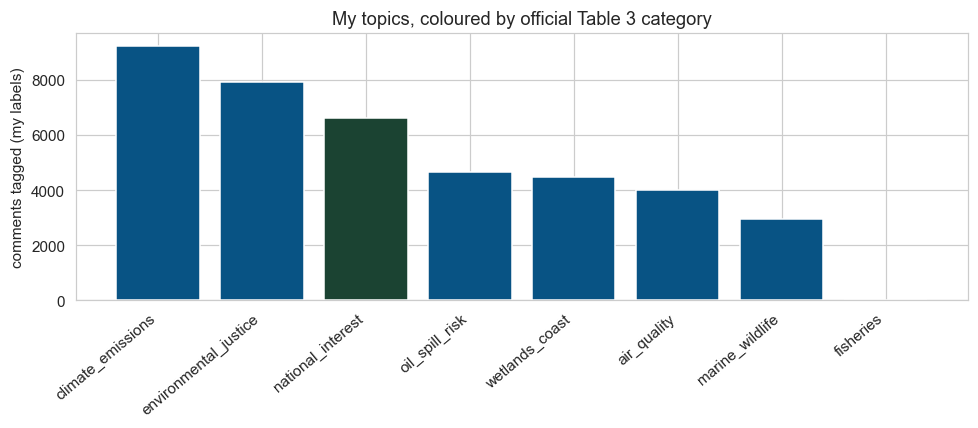

In [6]:
# Bar: my topic counts, coloured by official category
plt.figure(figsize=(9,4))
colors = {"Analysis":"#085384","General Opinion":"#1B4332","NEPA Process":"#6b705c"}
plt.bar(cross["my_topic"], cross["my_count"],
        color=[colors.get(c,"#888") for c in cross["official_category"]])
plt.xticks(rotation=40, ha="right"); plt.ylabel("comments tagged (my labels)")
plt.title("My topics, coloured by official Table 3 category")
plt.tight_layout(); plt.savefig("topic_comparison_crosswalk.png", bbox_inches="tight")
plt.show()


---
## Aggregate distribution vs Table 3 published counts

Category              mine   Table3   ratio
NEPA Process             0      120    0.00
General Opinion       6612      115   57.50
Analysis             33275      424   78.48


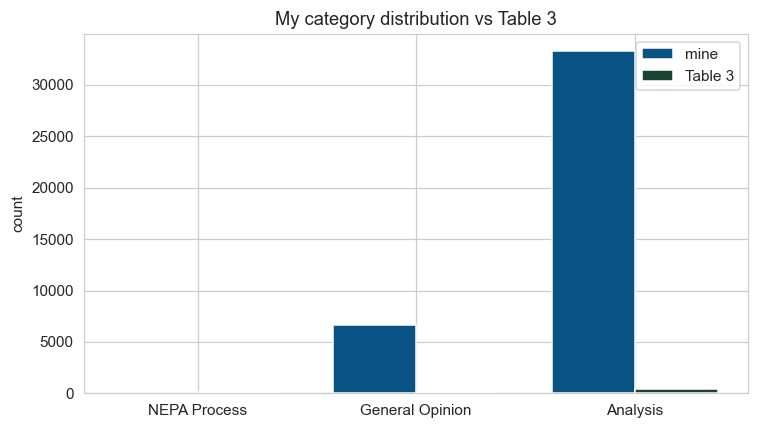


Note: scale differs (you label full docket; Table 3 is Round 1) — read as PROPORTIONS, not raw equality.


In [7]:
TABLE3 = {"NEPA Process":120, "General Opinion":115, "Analysis":424}

# my category counts on Round 1 
flag_to_cat = {m:v[1] for m,v in CROSSWALK.items()}
if ROUND_COL in apx.columns:
    pass

# count my comments per official category 
cat_counts = {c:0 for c in TABLE3}
for m in MY_TOPIC_FLAGS:
    if m in main.columns:
        cat_counts[flag_to_cat.get(m,"Analysis")] += int(main[m].sum())

print(f"{'Category':18s}{'mine':>8s}{'Table3':>9s}{'ratio':>8s}")
for c in TABLE3:
    mine=cat_counts.get(c,0); exp=TABLE3[c]
    print(f"{c:18s}{mine:8d}{exp:9d}{(mine/exp if exp else 0):8.2f}")

x=np.arange(len(TABLE3)); w=0.38
plt.figure(figsize=(7,4))
plt.bar(x-w/2,[cat_counts[c] for c in TABLE3],w,label="mine",color="#085384")
plt.bar(x+w/2,[TABLE3[c] for c in TABLE3],w,label="Table 3",color="#1B4332")
plt.xticks(x,list(TABLE3)); plt.ylabel("count"); plt.legend()
plt.title("My category distribution vs Table 3"); plt.tight_layout()
plt.savefig("topic_comparison_aggregate.png",bbox_inches="tight"); plt.show()
print("\nNote: scale differs (you label full docket; Table 3 is Round 1) — read as PROPORTIONS, not raw equality.")


---
##  Per-comment: comment-view  vs agency-response-view (official)

In [8]:
apx["topics_comment"]  = apx[COMMENT_COL].apply(extract_topics)
apx["topics_response"] = apx[RESPONSE_COL].apply(extract_topics)

def jacc(a,b):
    A,B=set(a),set(b)
    if not A and not B: return np.nan
    if not A or not B:  return 0.0
    return len(A&B)/len(A|B)

apx["jaccard"] = apx.apply(lambda r: jacc(r["topics_comment"],r["topics_response"]), axis=1)
both = apx[apx["jaccard"].notna()]
print(f"Comments comparable (≥1 topic on a side): {len(both):,}")
print(f"Mean Jaccard(comment, response):          {both['jaccard'].mean():.3f}")
print(f"Exact-set match:                          {(both['jaccard']==1.0).mean()*100:.1f}%")


Comments comparable (≥1 topic on a side): 1,628
Mean Jaccard(comment, response):          0.169
Exact-set match:                          7.4%


In [9]:
# Per topic agreement 
all_topics = list(TOPIC_KEYWORDS.keys())
agg=[]
for t in all_topics:
    in_resp = apx["topics_response"].apply(lambda L: t in L)
    in_comm = apx["topics_comment"].apply(lambda L: t in L)
    both_n  = int((in_resp & in_comm).sum())
    r_only  = int((in_resp & ~in_comm).sum())   # agency raised, comment didn't emphasise
    c_only  = int((~in_resp & in_comm).sum())   # comment raised, agency didn't address  <- RQ2
    rec = both_n/(both_n+r_only) if (both_n+r_only) else np.nan
    prec= both_n/(both_n+c_only) if (both_n+c_only) else np.nan
    agg.append({"topic":t,"both":both_n,"agency_only":r_only,"comment_only":c_only,
                "recall_vs_agency":rec,"precision_vs_agency":prec})
agg_df=pd.DataFrame(agg).sort_values("comment_only",ascending=False)
print(agg_df.to_string(index=False))
print("\nHigh 'comment_only' = public raised it but agency response didn't address it -> potential blind spot (RQ2).")


                            topic  both  agency_only  comment_only  recall_vs_agency  precision_vs_agency
                       Oil spills   149          116           175          0.562264             0.459877
                         Wildlife    48           42           167          0.533333             0.223256
                   Climate change   152          217           154          0.411924             0.496732
               Wetlands and coast    54           53           114          0.504673             0.321429
                      Air quality    30           84            99          0.263158             0.232558
Threatened and endangered species    36           50            65          0.418605             0.356436
                Marine ecosystems    21           26            44          0.446809             0.323077
         Greenhouse gas emissions    39          252            43          0.134021             0.475610
            Environmental justice    35       

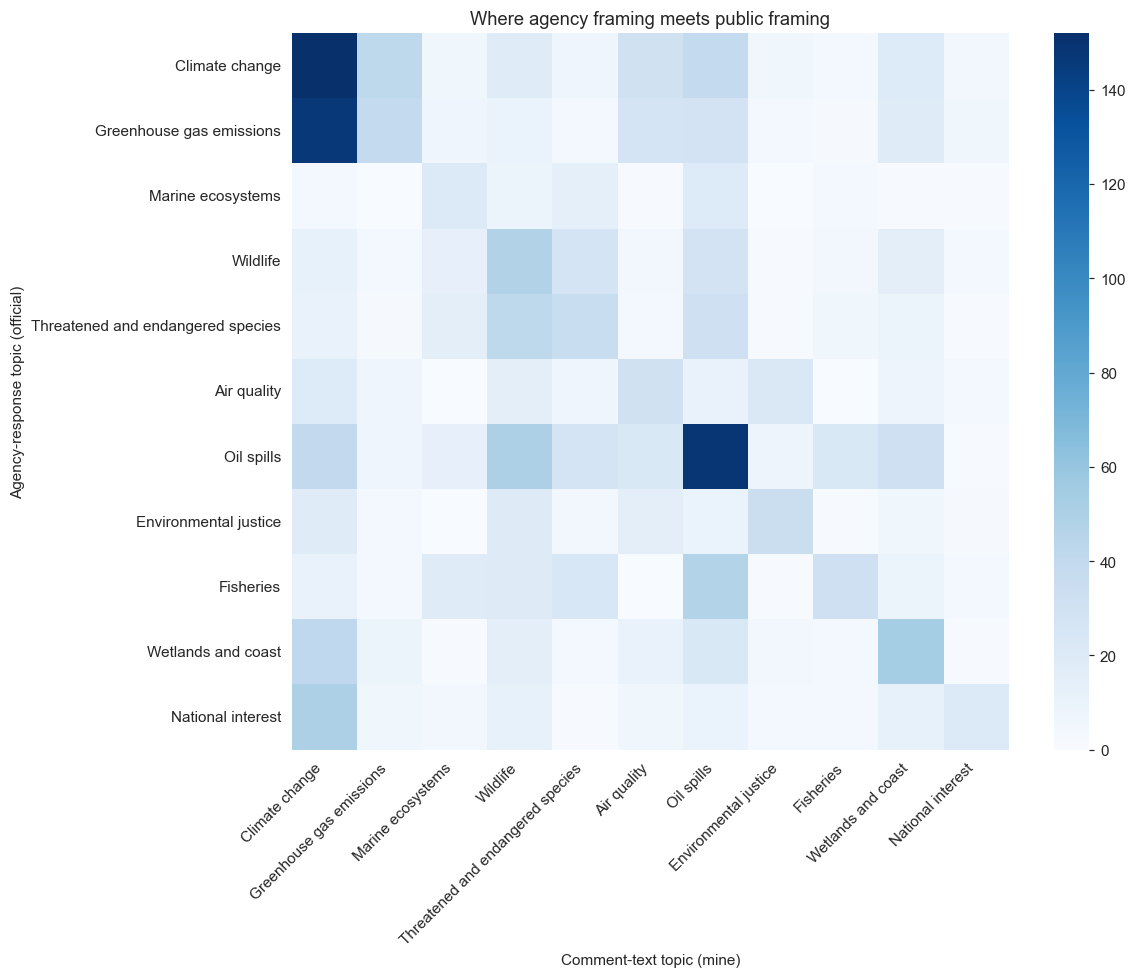

In [10]:
# Migration matrix
M = pd.DataFrame(0, index=all_topics, columns=all_topics)
for _,r in apx.iterrows():
    for a,b in product(r["topics_response"], r["topics_comment"]):
        M.loc[a,b]+=1
plt.figure(figsize=(11,9))
sns.heatmap(M, cmap="Blues", annot=False, cbar=True)
plt.xlabel("Comment-text topic (mine)"); plt.ylabel("Agency-response topic (official)")
plt.title("Where agency framing meets public framing")
plt.xticks(rotation=45,ha="right"); plt.tight_layout()
plt.savefig("topic_comparison_migration.png",bbox_inches="tight"); plt.show()


In [11]:
def fmt(L): return "|".join(L) if L else "NONE"
out = apx.copy()
out["topics_comment_s"]  = out["topics_comment"].apply(fmt)
out["topics_response_s"] = out["topics_response"].apply(fmt)
out["comment_only"] = out.apply(lambda r:[t for t in r["topics_comment"] if t not in r["topics_response"]],axis=1).apply(fmt)
out["agency_only"]  = out.apply(lambda r:[t for t in r["topics_response"] if t not in r["topics_comment"]],axis=1).apply(fmt)
keep=[ID_COL,COMMENT_COL,"topics_comment_s","topics_response_s","comment_only","agency_only","jaccard"]
keep=[c for c in keep if c in out.columns]
out[keep].to_csv("agency_vs_comment_disagreements.csv",index=False)
print("Saved agency_vs_comment_disagreements.csv")
print("\nFor the slide: pull 2-3 'comment_only' examples = public concerns the official response skipped.")


Saved agency_vs_comment_disagreements.csv

For the slide: pull 2-3 'comment_only' examples = public concerns the official response skipped.
